In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 파일 경로 지정
RAW_DIR = Path(r"C:\rookies6\medical-infrastructure-viz\data\aging\raw")
WELFARE_PATH = RAW_DIR / "senior_welfare_facilities_raw.csv"
CARE_PATH = RAW_DIR / "kosis_care_hospitals_raw.csv"

# 2. 데이터 불러오기
df_welfare = pd.read_csv(WELFARE_PATH, encoding="utf-8-sig")
df_nursing = pd.read_csv(CARE_PATH, encoding="utf-8-sig")

# -------------------------------------------------------------
# 3. 데이터 전처리 및 정제
# -------------------------------------------------------------

# (1) 복지시설 데이터: 시도명 정제 ('서울 Seoul' -> '서울')
df_welfare['시도_clean'] = df_welfare['시도'].apply(lambda x: str(x).split()[0])

# 복지 관련 주요 시설 수 합산 (2024년 기준)
welfare_cols = [
    '노인여가복지시설_경로당', '노인여가복지시설_복지관',
    '재가노인복지시설_방문요양서비스_시설수',
    '재가노인복지시설_주야간보호서비스_시설수',
    '재가노인복지시설_방문목욕서비스_시설수',
    '재가노인복지시설_방문간호서비스_시설수'
]

df_welfare['복지시설_합계'] = df_welfare[welfare_cols].sum(axis=1)

# 2024년 복지 데이터 추출
df_welfare_2024 = df_welfare[df_welfare['연도'] == 2024][['시도_clean', '복지시설_합계']].copy()

# (2) 요양병원 데이터 전처리 ('서울특별시' -> '서울')
# 전국 '계' 행 제외
df_nursing_sub = df_nursing[df_nursing['시도별(1)'] != '계'].copy()

# 시도명 표준화 맵핑
sido_map = {
    '서울특별시': '서울', '부산광역시': '부산', '대구광역시': '대구',
    '인천광역시': '인천', '광주광역시': '광주', '대전광역시': '대전',
    '울산광역시': '울산', '세종특별자치시': '세종', '경기도': '경기',
    '강원특별자치도': '강원', '충청북도': '충북', '충청남도': '충남',
    '전북특별자치도': '전북', '전라남도': '전남', '경상북도': '경북',
    '경상남도': '경남', '제주특별자치도': '제주'
}
df_nursing_sub['시도_clean'] = df_nursing_sub['시도별(1)'].map(sido_map)

# 2024년 요양병원 데이터 추출
df_nursing_2024 = df_nursing_sub[['시도_clean', '2024_의료기관_요양병원']].copy()
df_nursing_2024.rename(columns={'2024_의료기관_요양병원': '요양병원_수'}, inplace=True)

# (3) 두 데이터 병합
df_merged = pd.merge(df_welfare_2024, df_nursing_2024, on='시도_clean')

# 수치형 변환
df_merged['복지시설_합계'] = pd.to_numeric(df_merged['복지시설_합계'])
df_merged['요양병원_수'] = pd.to_numeric(df_merged['요양병원_수'])

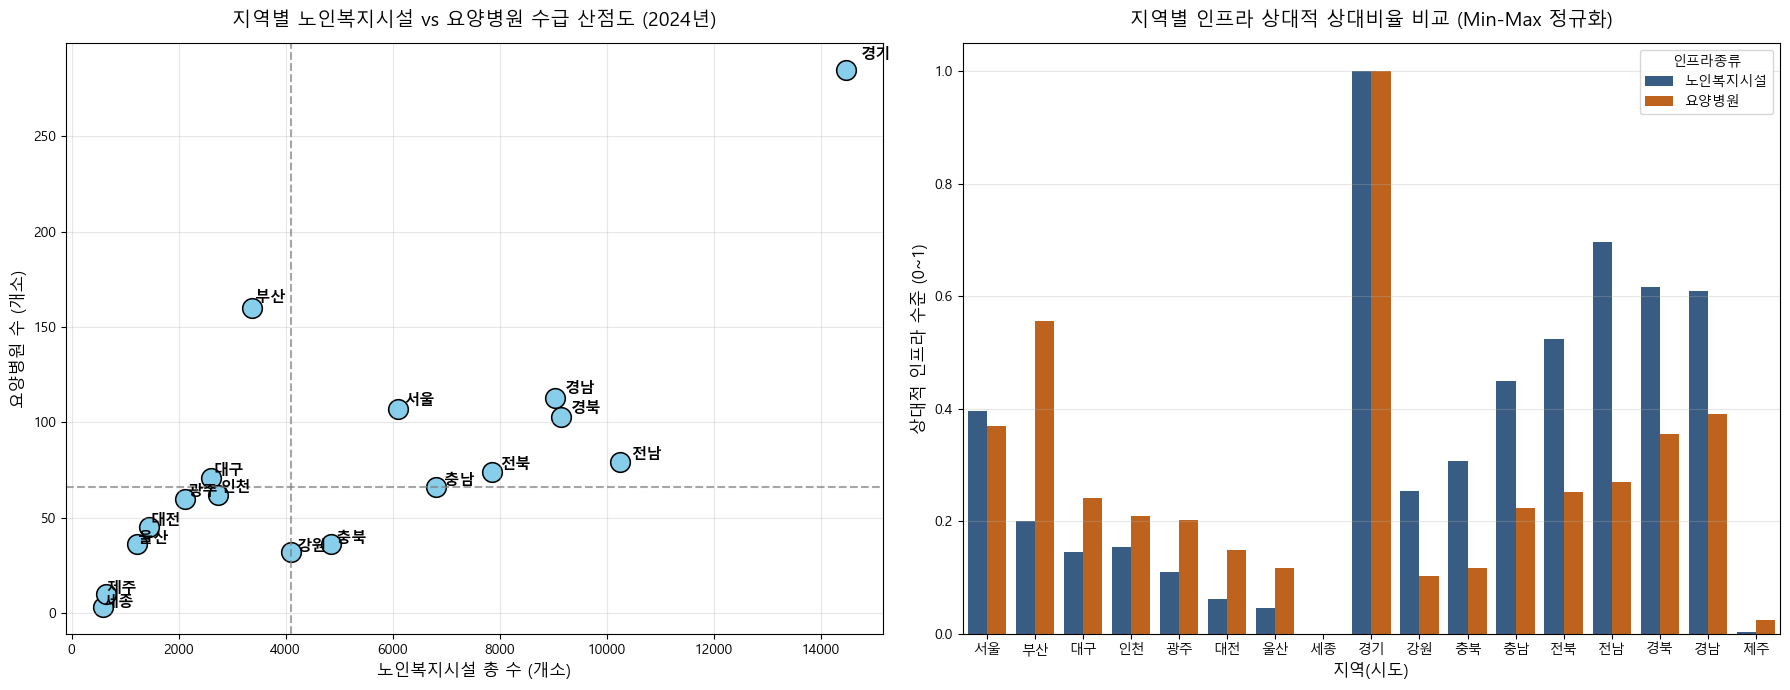

=== 2024년 지역별 복지시설 대비 요양병원 비율 TOP 5 (의료 우세) ===
  시도_clean  복지시설_합계  요양병원_수  복지_대비_의료비율(%)
1       부산     3370     160       4.747774
5       대전     1452      45       3.099174
6       울산     1216      36       2.960526
4       광주     2119      60       2.831524
2       대구     2602      71       2.728670

=== 2024년 지역별 복지시설 대비 요양병원 비율 BOTTOM 5 (복지/돌봄 우세) ===
   시도_clean  복지시설_합계  요양병원_수  복지_대비_의료비율(%)
7        세종      584       3       0.513699
10       충북     4848      36       0.742574
13       전남    10248      79       0.770882
9        강원     4106      32       0.779347
12       전북     7851      74       0.942555


In [6]:
# -------------------------------------------------------------
# 4. 시각화 (Plot 생성)
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# [Plot 1] 산점도 (Scatter Plot) - 4분면 수급 균형 분석
sns.scatterplot(
    data=df_merged, x='복지시설_합계', y='요양병원_수',
    s=200, color='skyblue', edgecolor='black', ax=axes[0]
)

# 중앙값 기준 4분면 가이드라인 추가
med_x = df_merged['복지시설_합계'].median()
med_y = df_merged['요양병원_수'].median()

axes[0].axvline(med_x, color='gray', linestyle='--', alpha=0.7)
axes[0].axhline(med_y, color='gray', linestyle='--', alpha=0.7)

# 지역 이름 텍스트 표시
for _, row in df_merged.iterrows():
    axes[0].text(
        row['복지시설_합계'] * 1.02, row['요양병원_수'] * 1.02,
        row['시도_clean'], fontsize=11, fontweight='bold'
    )

axes[0].set_title('지역별 노인복지시설 vs 요양병원 수급 산점도 (2024년)', fontsize=14, pad=12)
axes[0].set_xlabel('노인복지시설 총 수 (개소)', fontsize=12)
axes[0].set_ylabel('요양병원 수 (개소)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# [Plot 2] 이중 축 / 표준화 비교 막대 그래프
# 두 지표의 단위 차이가 크므로 Min-Max Scaling 적용 후 비교
df_merged['복지시설_정규화'] = (df_merged['복지시설_합계'] - df_merged['복지시설_합계'].min()) / (df_merged['복지시설_합계'].max() - df_merged['복지시설_합계'].min())
df_merged['요양병원_정규화'] = (df_merged['요양병원_수'] - df_merged['요양병원_수'].min()) / (df_merged['요양병원_수'].max() - df_merged['요양병원_수'].min())

df_plot = df_merged.melt(
    id_vars=['시도_clean'], 
    value_vars=['복지시설_정규화', '요양병원_정규화'],
    var_name='인프라종류', value_name='정규화점수'
)
df_plot['인프라종류'] = df_plot['인프라종류'].map({'복지시설_정규화': '노인복지시설', '요양병원_정규화': '요양병원'})

sns.barplot(
    data=df_plot, x='시도_clean', y='정규화점수', hue='인프라종류',
    palette=['#2b5c8f', '#d95f02'], ax=axes[1]
)

axes[1].set_title('지역별 인프라 상대적 상대비율 비교 (Min-Max 정규화)', fontsize=14, pad=12)
axes[1].set_xlabel('지역(시도)', fontsize=12)
axes[1].set_ylabel('상대적 인프라 수준 (0~1)', fontsize=12)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 5. 수급 불균형 도출 요약 출력
# -------------------------------------------------------------
df_merged['복지_대비_의료비율(%)'] = (df_merged['요양병원_수'] / df_merged['복지시설_합계']) * 100
print("=== 2024년 지역별 복지시설 대비 요양병원 비율 TOP 5 (의료 우세) ===")
print(df_merged.sort_values(by='복지_대비_의료비율(%)', ascending=False)[['시도_clean', '복지시설_합계', '요양병원_수', '복지_대비_의료비율(%)']].head())

print("\n=== 2024년 지역별 복지시설 대비 요양병원 비율 BOTTOM 5 (복지/돌봄 우세) ===")
print(df_merged.sort_values(by='복지_대비_의료비율(%)', ascending=True)[['시도_clean', '복지시설_합계', '요양병원_수', '복지_대비_의료비율(%)']].head())